# Lecture 5: Decision Trees & Random Forests

---

**From Single Splits to Forest Wisdom**

| Section | Topic |
|---------|-------|
| 0 | Motivation — Why Decision Trees? |
| 1 | How a Decision Tree Thinks |
| 2 | Gini vs Entropy — Splitting Criteria |
| 3 | Overfitting, Bias-Variance & Pruning |
| 4 | Regression Trees |
| 5 | Random Forest — The Power of the Crowd |
| 6 | Hyperparameter Tuning & Practical Tips |
| 7 | Practice Exercises |

---

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from sklearn.tree import _tree
import warnings

from sklearn.datasets import load_iris, make_regression
from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    plot_tree, export_text
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    GridSearchCV, cross_val_score, learning_curve, train_test_split
)
from sklearn.metrics import (
    accuracy_score, mean_squared_error,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

GREEN  = '#2ecc71'
RED    = '#e74c3c'
BLUE   = '#3498db'
ORANGE = '#f39c12'
PURPLE = '#9b59b6'
GRAY   = '#95a5a6'
PALETTE = [GREEN, RED, BLUE, ORANGE, PURPLE]

SEED = 42
np.random.seed(SEED)

print('All imports loaded successfully.')

All imports loaded successfully.


---
## Section 0: Motivation — Why Decision Trees?

Decision trees mimic how **humans naturally make decisions**. You already use them every day:

```
DOCTOR DIAGNOSIS (simplified):

         Temperature > 38°C?
        /                   \
      YES                    NO
       |                      |
  Cough present?          Rash present?
  /          \             /         \
YES           NO         YES          NO
 |             |          |            |
FLU?         COVID?     ALLERGY?     HEALTHY
```

### The 20-Questions Intuition
Think of training a tree as playing **"20 Questions"**:
- Each question should maximally reduce your **uncertainty**
- Good question: "Is it alive?" → splits possibilities roughly in half
- Bad question: "Is it exactly 3.7 cm tall?" → almost no information gained

Decision trees **formalise this intuition** with impurity measures (Gini, Entropy).

### Why Trees?
| Advantage | Detail |
|-----------|--------|
| **Interpretable** | Rules can be printed and explained |
| **No scaling needed** | Works on raw feature values |
| **Handles mixed types** | Numeric + categorical features |
| **Non-linear** | Captures complex patterns without feature engineering |

> **Real-world uses:** Credit scoring, medical diagnosis, customer churn, fraud detection.

---
## Section 1: How a Decision Tree Thinks

A decision tree learns a hierarchy of **if-then-else** rules that recursively split the
feature space into axis-aligned rectangular regions.

**Algorithm (CART — Classification and Regression Trees):**
1. At the current node, try every feature × every threshold
2. Pick the split that **maximally reduces impurity** (Gini or Entropy)
3. Recurse on each child node
4. Stop when: max depth reached, node is pure, or too few samples remain

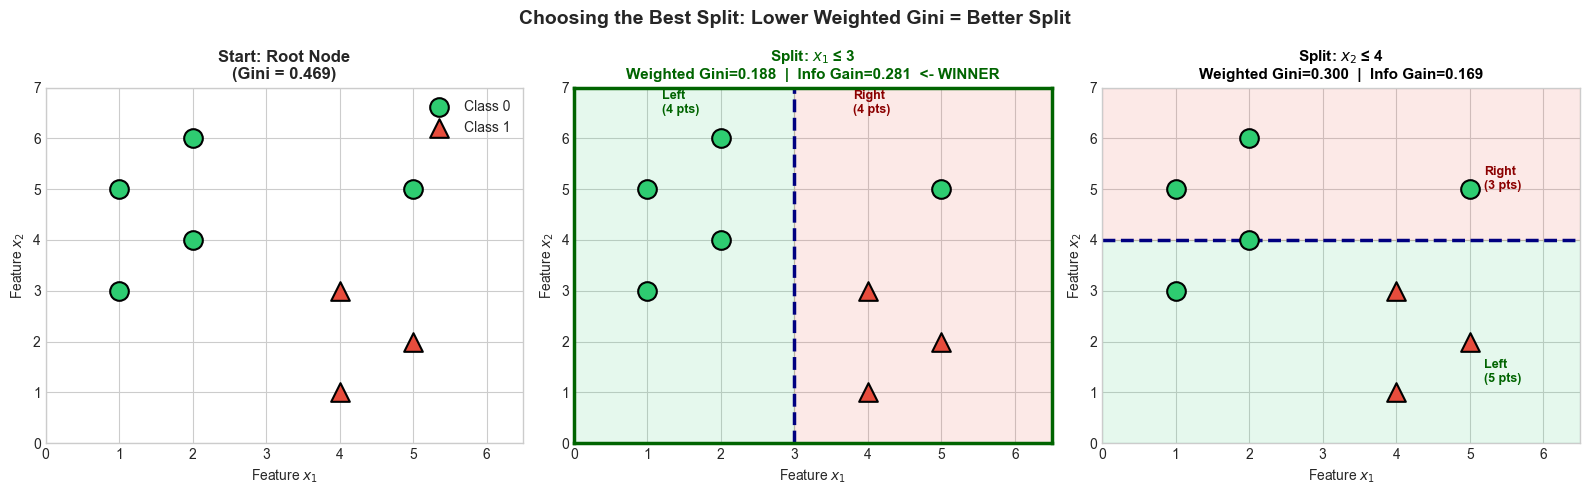

Best split: x1 <= 3  (weighted Gini = 0.188)


In [37]:
# ---------------------------------------------------------------
# 1.0  Step-by-step: how the tree picks the best split
# ---------------------------------------------------------------
# Toy dataset: 8 points, 2 features, 2 classes
X_toy = np.array([[1,3],[1,5],[2,4],[2,6],[4,1],[4,3],[5,2],[5,5]])
y_toy = np.array([0,   0,   0,   0,   1,   1,   1,   0  ])

def gini(labels):
    if len(labels) == 0:
        return 0.0
    p = np.mean(labels == 1)
    return 2 * p * (1 - p)

def weighted_gini(left, right):
    n = len(left) + len(right)
    return (len(left)/n)*gini(left) + (len(right)/n)*gini(right)

# Each entry: (latex label for plots, plain label for print, boolean mask)
split_candidates = [
    ('$x_1$ ≤ 3', 'x1 <= 3', X_toy[:, 0] <= 3),
    ('$x_2$ ≤ 4', 'x2 <= 4', X_toy[:, 1] <= 4),
]

# Pre-compute best split before drawing
wg_scores = {latex: weighted_gini(y_toy[mask], y_toy[~mask])
             for latex, _, mask in split_candidates}
best_split_label = min(wg_scores, key=wg_scores.get)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 0 – unsplit data
ax = axes[0]
for cls, color, marker in zip([0, 1], [GREEN, RED], ['o', '^']):
    mask = y_toy == cls
    ax.scatter(X_toy[mask, 0], X_toy[mask, 1],
               c=color, s=180, marker=marker,
               edgecolors='k', linewidths=1.5, zorder=3,
               label=f'Class {cls}')
ax.set_title('Start: Root Node\n(Gini = {:.3f})'.format(gini(y_toy)),
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 6.5); ax.set_ylim(0, 7)
ax.set_xlabel('Feature $x_1$'); ax.set_ylabel('Feature $x_2$')
ax.legend(fontsize=10)

for ax, (latex_label, plain_label, mask) in zip(axes[1:], split_candidates):
    wg = wg_scores[latex_label]
    info_gain = gini(y_toy) - wg
    is_winner = (latex_label == best_split_label)

    if 'x_1' in latex_label:
        threshold = 3
        ax.axvspan(0, threshold, alpha=0.12, color=GREEN)
        ax.axvspan(threshold, 7, alpha=0.12, color=RED)
        ax.axvline(threshold, color='navy', lw=2.5, ls='--')
        ax.text(1.2, 6.5, f'Left\n({mask.sum()} pts)', fontsize=9,
                color='darkgreen', fontweight='bold')
        ax.text(3.8, 6.5, f'Right\n({(~mask).sum()} pts)', fontsize=9,
                color='darkred', fontweight='bold')
    else:
        threshold = 4
        ax.axhspan(0, threshold, alpha=0.12, color=GREEN)
        ax.axhspan(threshold, 7, alpha=0.12, color=RED)
        ax.axhline(threshold, color='navy', lw=2.5, ls='--')
        ax.text(5.2, 1.2, f'Left\n({mask.sum()} pts)', fontsize=9,
                color='darkgreen', fontweight='bold')
        ax.text(5.2, 5.0, f'Right\n({(~mask).sum()} pts)', fontsize=9,
                color='darkred', fontweight='bold')

    for cls, color, marker in zip([0, 1], [GREEN, RED], ['o', '^']):
        m = y_toy == cls
        ax.scatter(X_toy[m, 0], X_toy[m, 1],
                   c=color, s=180, marker=marker,
                   edgecolors='k', linewidths=1.5, zorder=3)

    suffix = '  <- WINNER' if is_winner else ''
    title_color = 'darkgreen' if is_winner else 'black'
    ax.set_title(
        f'Split: {latex_label}\nWeighted Gini={wg:.3f}  |  Info Gain={info_gain:.3f}{suffix}',
        fontsize=11, fontweight='bold', color=title_color
    )
    if is_winner:
        for spine in ax.spines.values():
            spine.set_edgecolor('darkgreen')
            spine.set_linewidth(2.5)
    ax.set_xlim(0, 6.5); ax.set_ylim(0, 7)
    ax.set_xlabel('Feature $x_1$'); ax.set_ylabel('Feature $x_2$')

plt.suptitle('Choosing the Best Split: Lower Weighted Gini = Better Split',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_plain = next(p for l, p, _ in split_candidates if l == best_split_label)
print(f'Best split: {best_plain}  (weighted Gini = {wg_scores[best_split_label]:.3f})')

> **Key Takeaway:** The tree tries every possible feature × threshold pair and picks
> the one that creates the **purest child nodes** (lowest weighted Gini).
> This is a **greedy** algorithm — it does not look ahead past the current split.

> ⚠️ **Pitfall:** Greedy ≠ optimal. The globally best tree is NP-hard to find;
> CART finds a locally good one.

In [38]:
# ---------------------------------------------------------------
# 1.1  Load Iris & train a shallow tree
# ---------------------------------------------------------------
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

clf_tree = DecisionTreeClassifier(max_depth=3, random_state=SEED)
clf_tree.fit(X_iris, y_iris)

print(f'Training accuracy : {clf_tree.score(X_iris, y_iris):.3f}')
print(f'Number of leaves  : {clf_tree.get_n_leaves()}')
print(f'Tree depth        : {clf_tree.get_depth()}')

Training accuracy : 0.973
Number of leaves  : 5
Tree depth        : 3


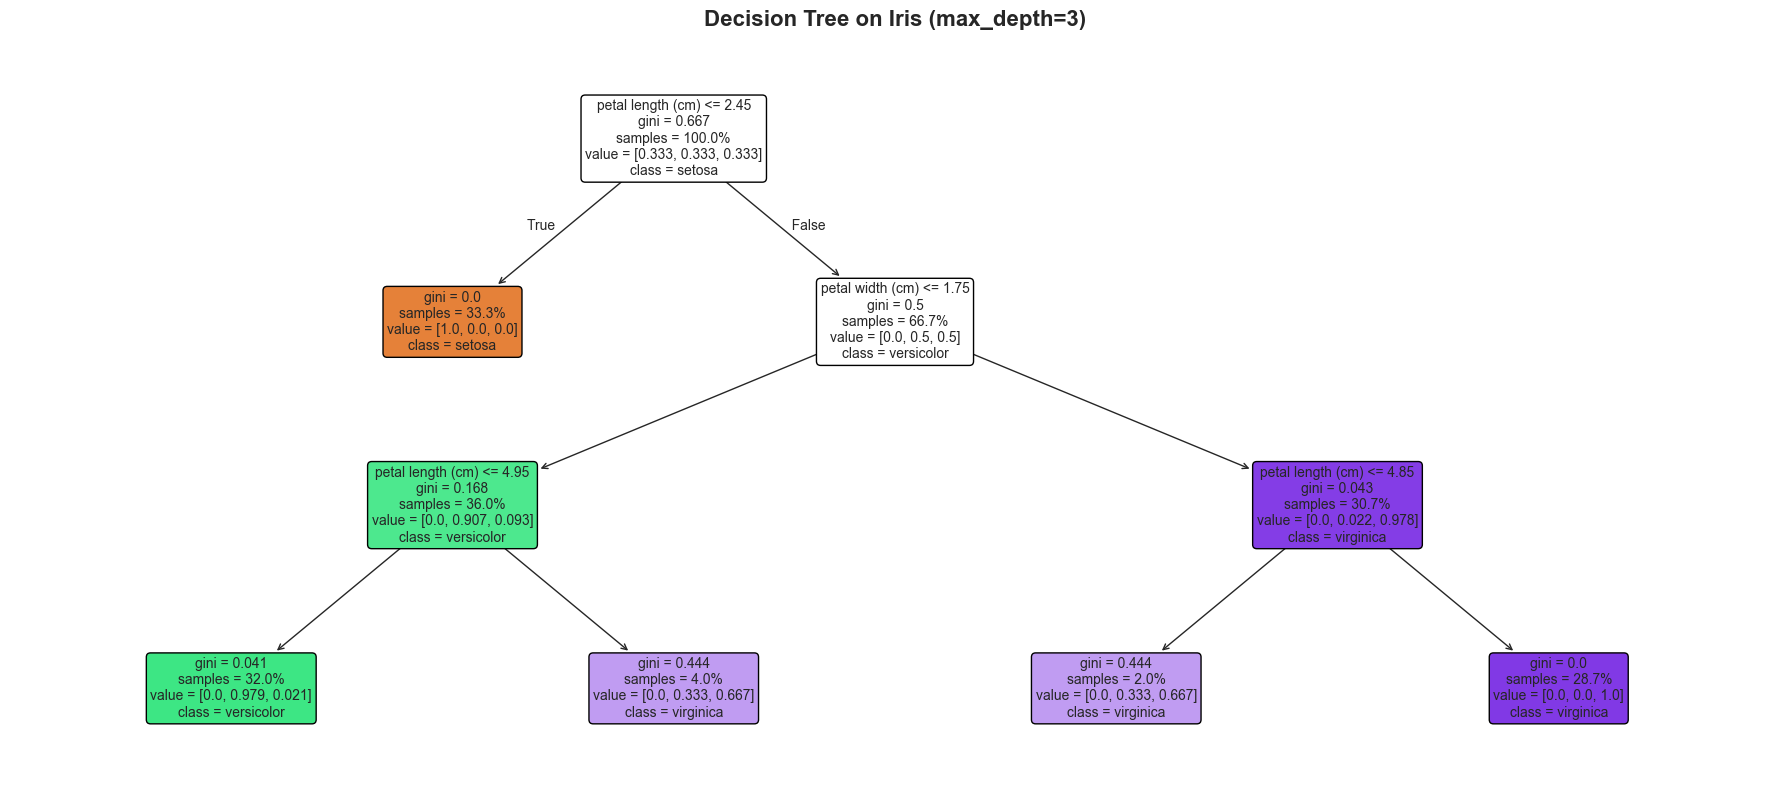

In [39]:
# ---------------------------------------------------------------
# 1.2  Visualize the tree structure
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    clf_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True, rounded=True, fontsize=10,
    ax=ax, impurity=True, proportion=True
)
ax.set_title('Decision Tree on Iris (max_depth=3)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [40]:
# ---------------------------------------------------------------
# 1.3  Export the tree as human-readable if-else rules
# ---------------------------------------------------------------
print('=== Tree Rules (text) ===\n')
print(export_text(clf_tree, feature_names=list(iris.feature_names)))

# ---------------------------------------------------------------
# Bonus: convert tree to actual Python code
# ---------------------------------------------------------------
def tree_to_code(tree_model, feature_names):
    """Print the trained tree as executable Python if-else code."""
    tree_  = tree_model.tree_
    fname  = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else 'undefined'
        for i in tree_.feature
    ]
    safe_names = [n.replace(' ', '_').replace('(', '').replace(')', '') for n in feature_names]
    print('def predict({}):'.format(', '.join(safe_names)))

    def recurse(node, depth):
        indent = '    ' * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = fname[node].replace(' ', '_').replace('(', '').replace(')', '')
            thr  = tree_.threshold[node]
            print(f'{indent}if {name} <= {thr:.4f}:')
            recurse(tree_.children_left[node],  depth + 1)
            print(f'{indent}else:  # > {thr:.4f}')
            recurse(tree_.children_right[node], depth + 1)
        else:
            cls = tree_model.classes_[np.argmax(tree_.value[node])]
            cls_name = iris.target_names[cls]
            print(f'{indent}return "{cls_name}"')

    recurse(0, 1)

print('\n=== Same tree as Python code ===\n')
tree_to_code(clf_tree, list(iris.feature_names))

=== Tree Rules (text) ===

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2


=== Same tree as Python code ===

def predict(sepal_length_cm, sepal_width_cm, petal_length_cm, petal_width_cm):
    if petal_length_cm <= 2.4500:
        return "setosa"
    else:  # > 2.4500
        if petal_width_cm <= 1.7500:
            if petal_length_cm <= 4.9500:
                return "versicolor"
            else:  # > 4.9500
                return "virginica"
        else:  # > 1.7500
            if petal_length_cm <= 4.8500:
                return "virginica"
            else:  # > 4.8500
                return "virginica"


> **Key Takeaway:** Every decision tree is equivalent to a set of **if-else rules**.
> This makes trees completely transparent — you can print the logic, explain it to
> a stakeholder, or even deploy it without scikit-learn.

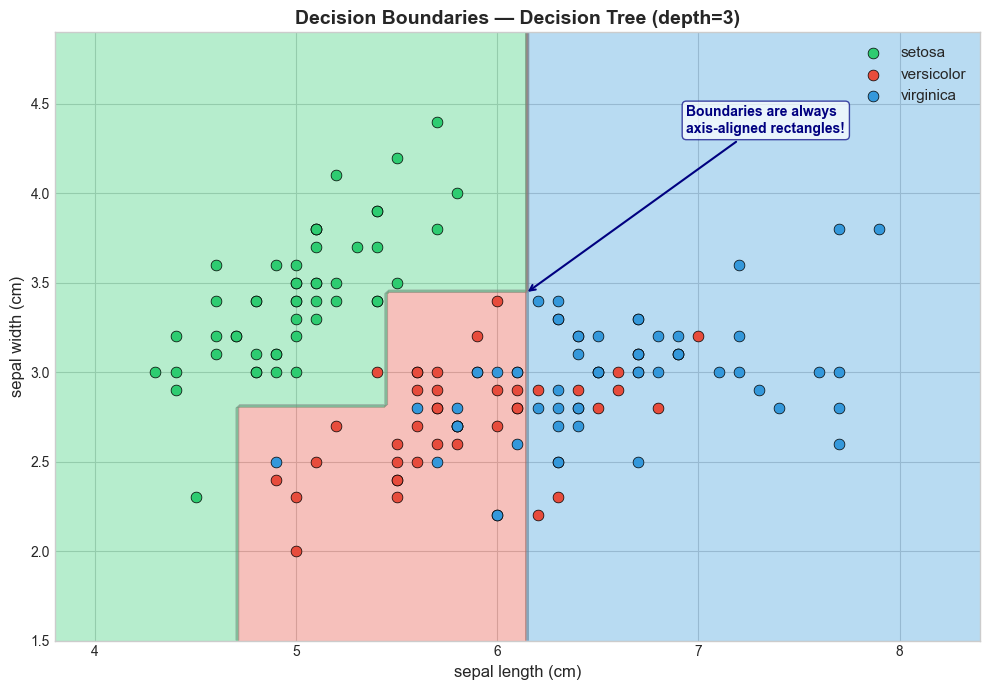

In [41]:
# ---------------------------------------------------------------
# 1.4  Decision boundaries in 2-D (first two Iris features)
# ---------------------------------------------------------------
X_2d = X_iris[:, :2]
clf_2d = DecisionTreeClassifier(max_depth=3, random_state=SEED)
clf_2d.fit(X_2d, y_iris)

h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
cmap_bg = ListedColormap([GREEN + '55', RED + '55', BLUE + '55'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
ax.contour(xx, yy, Z, colors='grey', linewidths=0.5, alpha=0.6)

for idx, (name, color) in enumerate(zip(iris.target_names, [GREEN, RED, BLUE])):
    mask = y_iris == idx
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=name, edgecolors='k', s=60, linewidths=0.5, zorder=3)

ax.set_xlabel(iris.feature_names[0], fontsize=12)
ax.set_ylabel(iris.feature_names[1], fontsize=12)
ax.set_title('Decision Boundaries — Decision Tree (depth=3)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

# Find the step corner: where two boundary segments meet at a right angle.
# Detect boundary pixels by comparing each cell to its right/upper neighbour.
corner_x, corner_y = None, None
for i in range(1, Z.shape[0] - 1):
    for j in range(1, Z.shape[1] - 1):
        h_change = Z[i, j] != Z[i, j + 1]   # horizontal boundary (vertical edge)
        v_change = Z[i, j] != Z[i + 1, j]   # vertical boundary (horizontal edge)
        if h_change and v_change:
            corner_x, corner_y = xx[i, j], yy[i, j]
            break
    if corner_x is not None:
        break

if corner_x is None:
    corner_x, corner_y = 5.5, 3.0  # fallback

ax.annotate('Boundaries are always\naxis-aligned rectangles!',
            xy=(corner_x, corner_y),
            xytext=(corner_x + 0.8, corner_y + 0.9),
            arrowprops=dict(arrowstyle='->', color='navy', lw=1.5),
            fontsize=10, color='navy', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='navy'))

plt.tight_layout()
plt.show()

> **Key Takeaway:** Decision tree boundaries are always **axis-aligned rectangles**.
> The tree cannot learn diagonal or curved boundaries — it approximates them
> with a series of rectangular splits.

> ⚠️ **Implication:** If the true decision boundary is diagonal, a tree needs many
> more splits than a linear model to approximate it.

---
## Section 2: Gini vs Entropy — Splitting Criteria

At each node the tree must choose the feature and threshold that produce the
**"purest" child nodes**. Two popular impurity measures:

| Measure | Formula (binary) | Range | Max at |
|---------|-----------------|-------|--------|
| **Gini** | $G(p) = 2p(1-p)$ | [0, 0.5] | p = 0.5 |
| **Entropy** | $H(p) = -p\log_2 p - (1-p)\log_2(1-p)$ | [0, 1] | p = 0.5 |

Both are **0 when the node is pure** and **maximum when perfectly mixed (p=0.5)**.

**Information Gain** = Impurity(parent) − weighted average Impurity(children)

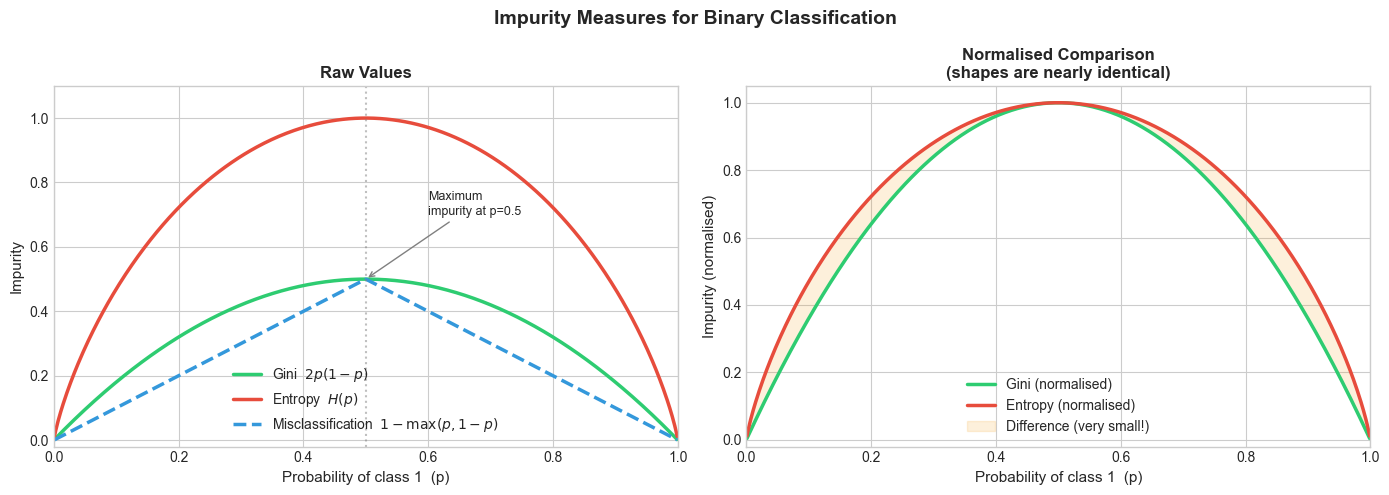

In [42]:
# ---------------------------------------------------------------
# 2.1  Gini vs Entropy as functions of p
# ---------------------------------------------------------------
p = np.linspace(0.001, 0.999, 500)

gini_vals    = 2 * p * (1 - p)
entropy_vals = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
entropy_norm = entropy_vals / entropy_vals.max()  # scale to [0,1] for comparison
misclass     = 1 - np.maximum(p, 1 - p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: raw values
ax = axes[0]
ax.plot(p, gini_vals,    color=GREEN,  lw=2.5, label='Gini  $2p(1-p)$')
ax.plot(p, entropy_vals, color=RED,    lw=2.5, label='Entropy  $H(p)$')
ax.plot(p, misclass,     color=BLUE,   lw=2.5, ls='--',
        label='Misclassification  $1-\\max(p,1-p)$')
ax.axvline(0.5, color='gray', ls=':', alpha=0.5)
ax.annotate('Maximum\nimpurity at p=0.5', xy=(0.5, 0.5), xytext=(0.6, 0.7),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
ax.set_xlabel('Probability of class 1  (p)', fontsize=11)
ax.set_ylabel('Impurity', fontsize=11)
ax.set_title('Raw Values', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(-0.02, 1.1)

# Panel 2: normalized to same scale for shape comparison
ax = axes[1]
ax.plot(p, gini_vals / gini_vals.max(),    color=GREEN,  lw=2.5, label='Gini (normalised)')
ax.plot(p, entropy_norm,                   color=RED,    lw=2.5, label='Entropy (normalised)')
ax.fill_between(p,
                gini_vals / gini_vals.max(),
                entropy_norm,
                alpha=0.15, color=ORANGE,
                label='Difference (very small!)')
ax.set_xlabel('Probability of class 1  (p)', fontsize=11)
ax.set_ylabel('Impurity (normalised)', fontsize=11)
ax.set_title('Normalised Comparison\n(shapes are nearly identical)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(-0.02, 1.05)

plt.suptitle('Impurity Measures for Binary Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Key Takeaway:** Gini and Entropy look almost identical when normalised.
> In practice they usually produce the **same tree**.
> Use `criterion='gini'` (default) — it's slightly faster (no log computation).
> Never use misclassification error for growing trees: it's insensitive to
> probability changes within a leaf.

In [43]:
# ---------------------------------------------------------------
# 2.2  Manual step-by-step split calculation
# ---------------------------------------------------------------
print('=' * 65)
print('  MANUAL INFORMATION GAIN CALCULATION')
print('=' * 65)

labels  = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
feature = np.array([1, 2, 3, 4, 5, 3, 6, 7, 8, 9])

print(f'\nFeature : {feature}')
print(f'Labels  : {labels}')
parent_gini = 2 * 0.5 * 0.5
print(f'Parent Gini = 2*0.5*0.5 = {parent_gini:.4f}  (perfectly mixed)')

best_thresh, best_ig = None, -np.inf
for thresh in [5, 4]:
    left  = labels[feature <= thresh]
    right = labels[feature > thresh]
    n     = len(labels)
    p_l   = np.mean(left  == 1)
    p_r   = np.mean(right == 1)
    g_l   = 2 * p_l * (1 - p_l)
    g_r   = 2 * p_r * (1 - p_r)
    wg    = (len(left)/n)*g_l + (len(right)/n)*g_r
    ig    = parent_gini - wg
    print(f'\n--- Candidate split: feature <= {thresh} ---')
    print(f'  Left  {left}  p={p_l:.2f}  Gini={g_l:.4f}')
    print(f'  Right {right}  p={p_r:.2f}  Gini={g_r:.4f}')
    print(f'  Weighted Gini = {wg:.4f}  |  Info Gain = {ig:.4f}')
    if ig > best_ig:
        best_ig, best_thresh = ig, thresh

print(f'\n>>> Best split: feature <= {best_thresh}  (Info Gain = {best_ig:.4f})')

  MANUAL INFORMATION GAIN CALCULATION

Feature : [1 2 3 4 5 3 6 7 8 9]
Labels  : [0 0 0 0 0 1 1 1 1 1]
Parent Gini = 2*0.5*0.5 = 0.5000  (perfectly mixed)

--- Candidate split: feature <= 5 ---
  Left  [0 0 0 0 0 1]  p=0.17  Gini=0.2778
  Right [1 1 1 1]  p=1.00  Gini=0.0000
  Weighted Gini = 0.1667  |  Info Gain = 0.3333

--- Candidate split: feature <= 4 ---
  Left  [0 0 0 0 1]  p=0.20  Gini=0.3200
  Right [0 1 1 1 1]  p=0.80  Gini=0.3200
  Weighted Gini = 0.3200  |  Info Gain = 0.1800

>>> Best split: feature <= 5  (Info Gain = 0.3333)


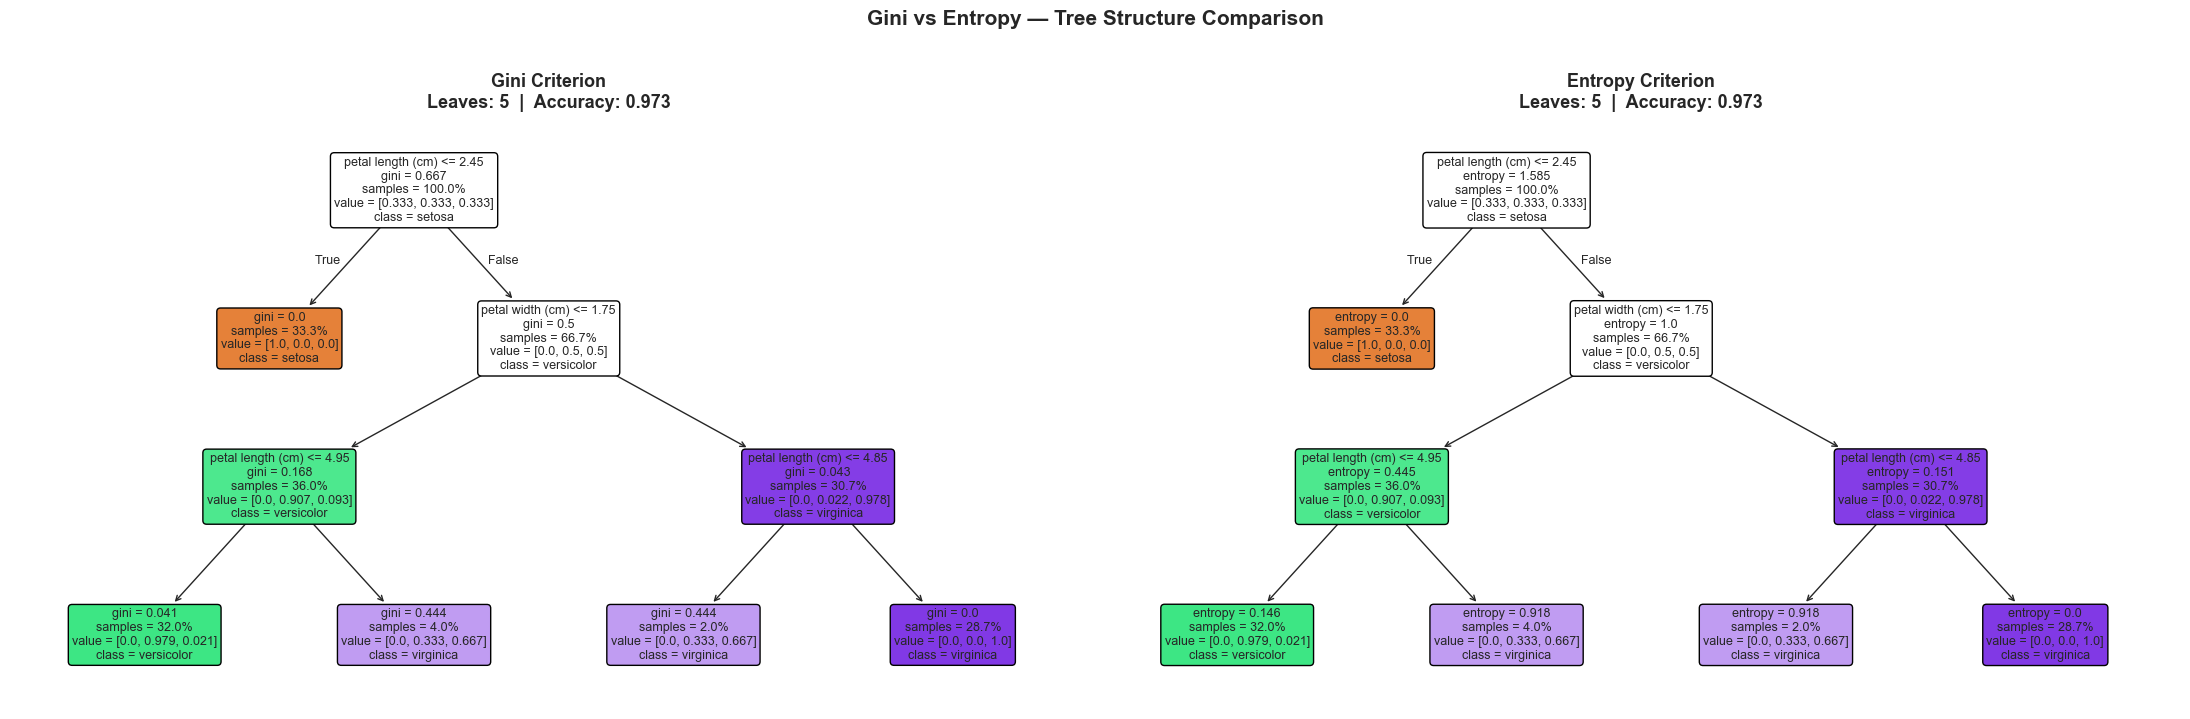

In [44]:
# ---------------------------------------------------------------
# 2.3  Side-by-side tree comparison: Gini vs Entropy
# ---------------------------------------------------------------
clf_gini    = DecisionTreeClassifier(criterion='gini',    max_depth=3, random_state=SEED)
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=SEED)
clf_gini.fit(X_iris, y_iris)
clf_entropy.fit(X_iris, y_iris)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
for ax, model, title in zip(axes,
                             [clf_gini, clf_entropy],
                             ['Gini Criterion', 'Entropy Criterion']):
    plot_tree(model, feature_names=iris.feature_names,
              class_names=iris.target_names,
              filled=True, rounded=True, fontsize=9,
              impurity=True, proportion=True, ax=ax)
    acc = model.score(X_iris, y_iris)
    ax.set_title(f'{title}\nLeaves: {model.get_n_leaves()}  |  Accuracy: {acc:.3f}',
                 fontsize=13, fontweight='bold')

plt.suptitle('Gini vs Entropy — Tree Structure Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Key Takeaway:** Same splits, same accuracy. For most real datasets
> `gini` and `entropy` produce **identical or nearly identical trees**.
> Stick with `gini` unless you have a specific reason to change.

---
## Section 3: Overfitting, Bias-Variance & Pruning

Decision trees are **high-variance** learners. Without constraints, a tree will
grow until every training sample is in its own leaf — **perfectly memorising** the
training data but generalising poorly.

### The Bias-Variance Tradeoff

| Model Complexity | Bias | Variance | Result |
|-----------------|------|----------|--------|
| Too simple (shallow tree) | High | Low | **Underfitting** |
| Just right | Low | Low | **Good generalisation** |
| Too complex (deep tree) | Low | High | **Overfitting** |

**Solutions:** `max_depth`, `min_samples_split`, `min_samples_leaf`, `ccp_alpha`

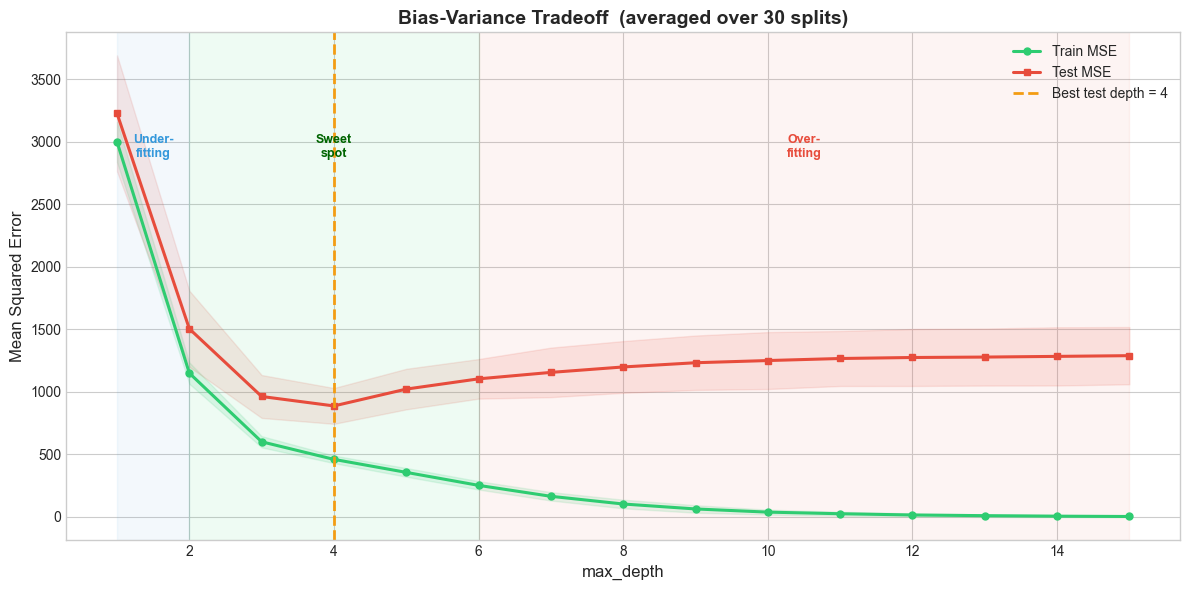

In [45]:
# ---------------------------------------------------------------
# 3.1  Bias-Variance tradeoff visualised on synthetic data
# ---------------------------------------------------------------
np.random.seed(SEED)
X_bv, y_bv = make_regression(n_samples=200, n_features=1, noise=25, random_state=SEED)

depths  = list(range(1, 16))
n_trials = 30
train_mses, test_mses = [], []
train_stds, test_stds = [], []

for d in depths:
    tr_scores, te_scores = [], []
    for seed in range(n_trials):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_bv, y_bv, test_size=0.25, random_state=seed
        )
        m = DecisionTreeRegressor(max_depth=d, random_state=seed)
        m.fit(X_tr, y_tr)
        tr_scores.append(mean_squared_error(y_tr, m.predict(X_tr)))
        te_scores.append(mean_squared_error(y_te, m.predict(X_te)))
    train_mses.append(np.mean(tr_scores))
    test_mses.append(np.mean(te_scores))
    train_stds.append(np.std(tr_scores))
    test_stds.append(np.std(te_scores))

train_mses = np.array(train_mses)
test_mses  = np.array(test_mses)

best_d = depths[np.argmin(test_mses)]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(depths, train_mses, 'o-', color=GREEN, lw=2.2, ms=5, label='Train MSE')
ax.plot(depths, test_mses,  's-', color=RED,   lw=2.2, ms=5, label='Test MSE')
ax.fill_between(depths,
                train_mses - np.array(train_stds),
                train_mses + np.array(train_stds),
                alpha=0.12, color=GREEN)
ax.fill_between(depths,
                test_mses - np.array(test_stds),
                test_mses + np.array(test_stds),
                alpha=0.12, color=RED)

ax.axvline(best_d, color=ORANGE, ls='--', lw=2,
           label=f'Best test depth = {best_d}')

# Region backgrounds (non-overlapping)
underfit_end = max(2, best_d - 2)
overfit_start = min(best_d + 2, 14)
ax.axvspan(1, underfit_end,       alpha=0.06, color=BLUE)
ax.axvspan(underfit_end, overfit_start, alpha=0.08, color=GREEN)
ax.axvspan(overfit_start, 15,    alpha=0.06, color=RED)

# Place text labels in the upper portion of each region (use axis-fraction y)
y_top = ax.get_ylim()[1] if ax.get_ylim()[1] < 1e6 else test_mses[0]
label_y = test_mses.max() * 0.95
ax.text((1 + underfit_end) / 2,       label_y, 'Under-\nfitting',
        ha='center', va='top', fontsize=9, color=BLUE,      fontweight='bold')
ax.text((underfit_end + overfit_start) / 2, label_y, 'Sweet\nspot',
        ha='center', va='top', fontsize=9, color='darkgreen', fontweight='bold')
ax.text((overfit_start + 15) / 2,     label_y, 'Over-\nfitting',
        ha='center', va='top', fontsize=9, color=RED,        fontweight='bold')

ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title(f'Bias-Variance Tradeoff  (averaged over {n_trials} splits)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

> **Key Takeaway:**
> - **Train MSE always decreases** as depth increases (tree memorises data)
> - **Test MSE has a U-shape** — first decreases (less bias), then increases (more variance)
> - The **minimum of the test curve** is the sweet spot
> - Shaded bands show variance across random splits — deeper trees are more unstable

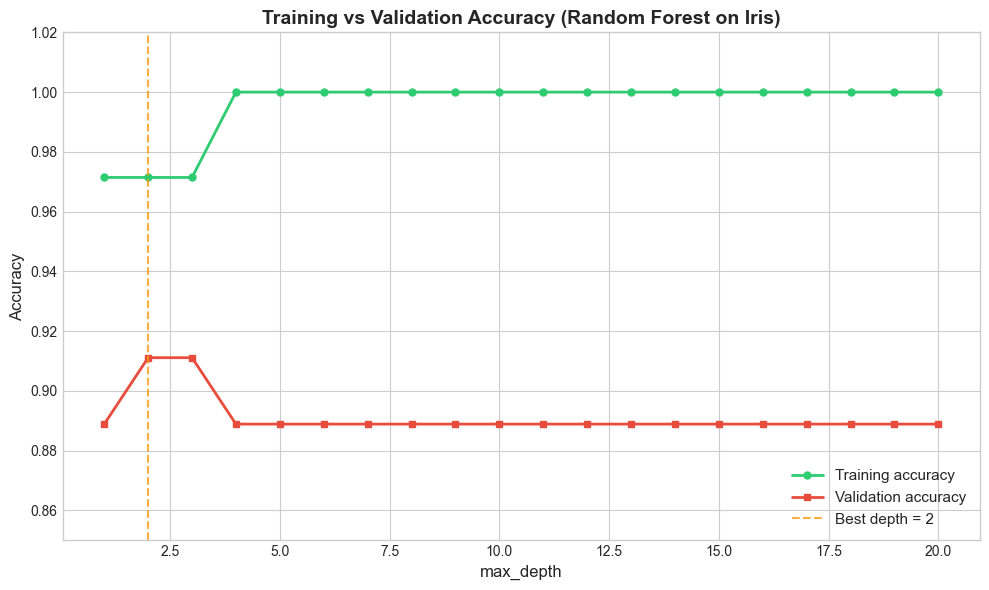

In [46]:
# ---------------------------------------------------------------
# 3.2  Overfitting curves on Iris: train vs validation accuracy
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=SEED, stratify=y_iris
)

depth_range  = range(1, 21)
train_scores = []
test_scores  = []

for d in depth_range:
    rf_d = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=SEED)
    rf_d.fit(X_train, y_train)
    train_scores.append(rf_d.score(X_train, y_train))
    test_scores.append(rf_d.score(X_test, y_test))

best_depth = list(depth_range)[np.argmax(test_scores)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depth_range, train_scores, 'o-', color=GREEN, lw=2, ms=5, label='Training accuracy')
ax.plot(depth_range, test_scores,  's-', color=RED,   lw=2, ms=5, label='Validation accuracy')
ax.axvline(best_depth, color=ORANGE, ls='--', alpha=0.8,
           label=f'Best depth = {best_depth}')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Training vs Validation Accuracy (Random Forest on Iris)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.85, 1.02)
plt.tight_layout()
plt.show()

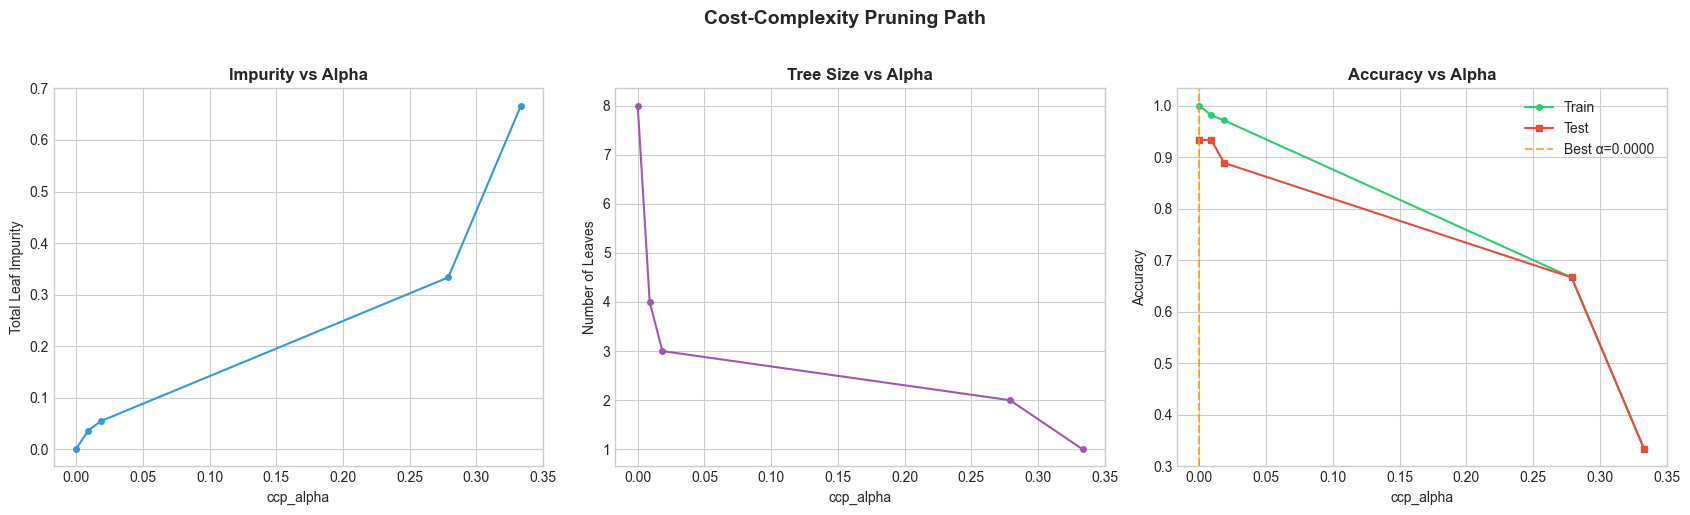

In [47]:
# ---------------------------------------------------------------
# 3.3  Cost-Complexity Pruning (ccp_alpha)
# ---------------------------------------------------------------
# Grow full tree, then find the pruning path
clf_full = DecisionTreeClassifier(random_state=SEED)
clf_full.fit(X_train, y_train)

path       = clf_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

train_acc_list, test_acc_list, n_leaves_list = [], [], []

for alpha in ccp_alphas:
    clf_p = DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED)
    clf_p.fit(X_train, y_train)
    train_acc_list.append(clf_p.score(X_train, y_train))
    test_acc_list.append(clf_p.score(X_test, y_test))
    n_leaves_list.append(clf_p.get_n_leaves())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(ccp_alphas, impurities,  'o-', color=BLUE, ms=4)
axes[0].set_xlabel('ccp_alpha'); axes[0].set_ylabel('Total Leaf Impurity')
axes[0].set_title('Impurity vs Alpha', fontweight='bold')

axes[1].plot(ccp_alphas, n_leaves_list, 'o-', color=PURPLE, ms=4)
axes[1].set_xlabel('ccp_alpha'); axes[1].set_ylabel('Number of Leaves')
axes[1].set_title('Tree Size vs Alpha', fontweight='bold')

best_alpha_idx = int(np.argmax(test_acc_list))
axes[2].plot(ccp_alphas, train_acc_list, 'o-', color=GREEN, ms=4, label='Train')
axes[2].plot(ccp_alphas, test_acc_list,  's-', color=RED,   ms=4, label='Test')
axes[2].axvline(ccp_alphas[best_alpha_idx], color=ORANGE, ls='--', alpha=0.8,
                label=f'Best α={ccp_alphas[best_alpha_idx]:.4f}')
axes[2].set_xlabel('ccp_alpha'); axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy vs Alpha', fontweight='bold')
axes[2].legend()

plt.suptitle('Cost-Complexity Pruning Path', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Key Takeaway:** `ccp_alpha` controls pruning — higher alpha = fewer leaves = simpler tree.
> At some threshold the test accuracy peaks, then drops (underfitting).
> Use cross-validation to find the optimal `ccp_alpha`.

---
## Section 4: Regression Trees

Decision trees work for **regression** too! Instead of class labels, each leaf
predicts the **mean** of the training targets that fall into that region.

The split criterion becomes **MSE reduction** (variance reduction):

$$\text{MSE}(S) = \frac{1}{|S|}\sum_{i \in S}(y_i - \bar{y}_S)^2$$

The tree picks the split that minimises the **weighted MSE** of the two children.

> Result: A regression tree makes **piecewise-constant (step-function) predictions**.

In [48]:
# ---------------------------------------------------------------
# 4.1  Load Position_Salaries data
# ---------------------------------------------------------------
salary_df = pd.read_csv('../Position_Salaries.csv')
print(salary_df.to_string(index=False))

X_sal = salary_df[['Level']].values
y_sal = salary_df['Salary'].values

         Position  Level  Salary
 Business Analyst      1   45000
Junior Consultant      2   50000
Senior Consultant      3   60000
          Manager      4   80000
  Country Manager      5  110000
   Region Manager      6  150000
          Partner      7  200000
   Senior Partner      8  300000
          C-level      9  500000
              CEO     10 1000000


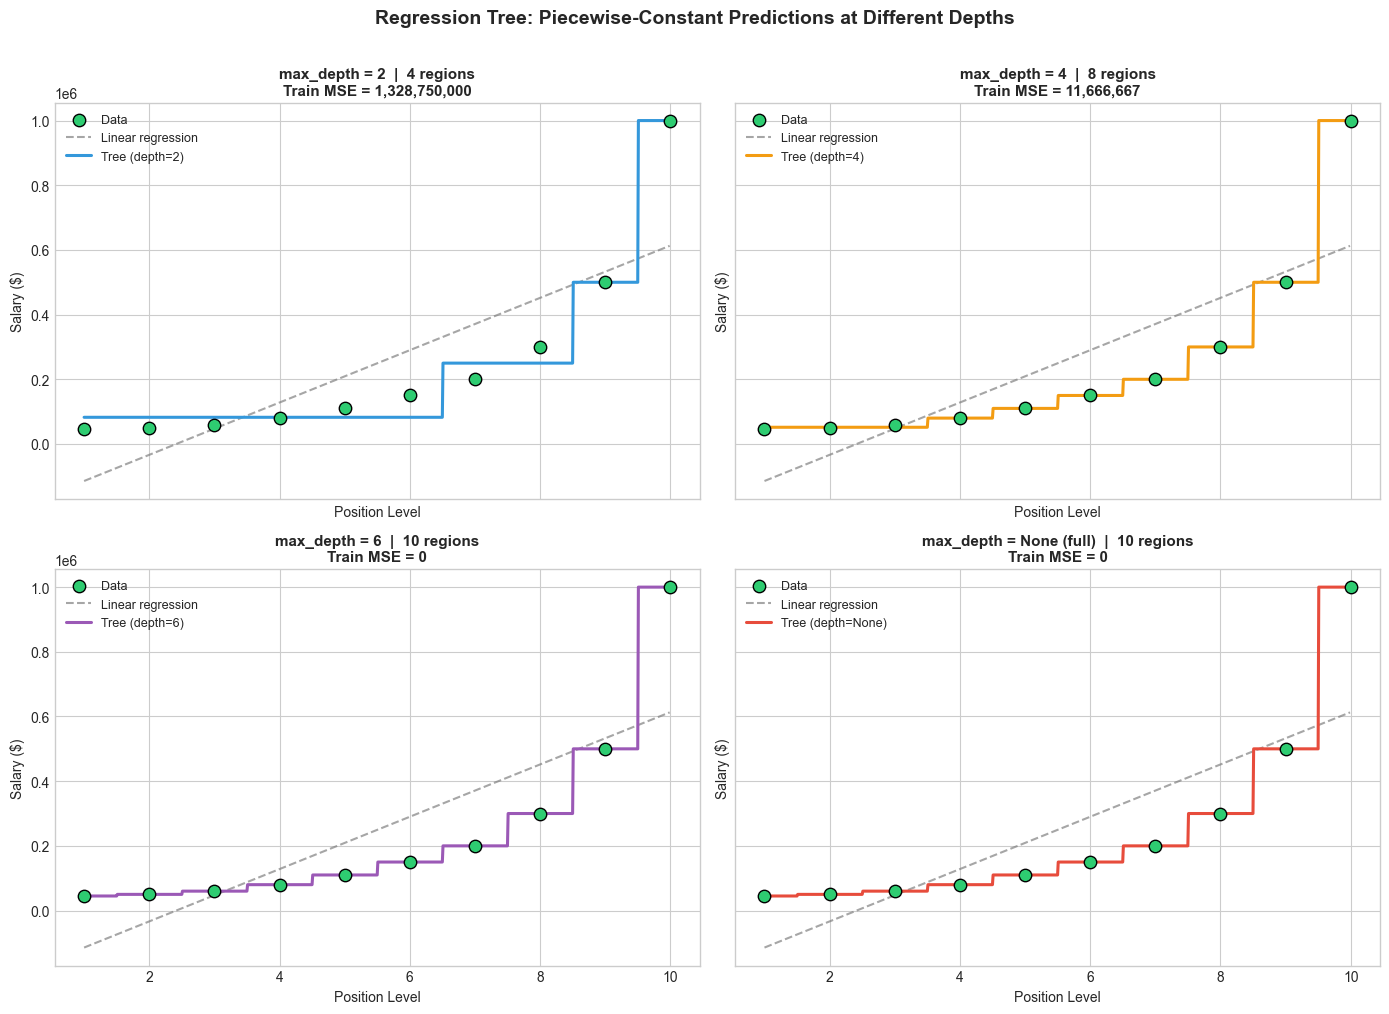

In [49]:
# ---------------------------------------------------------------
# 4.2  Regression trees at different depths + linear baseline
# ---------------------------------------------------------------
X_grid_sal = np.arange(X_sal.min(), X_sal.max(), 0.01).reshape(-1, 1)
depths_reg = [2, 4, 6, None]
colors_d   = [BLUE, ORANGE, PURPLE, RED]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
lr = LinearRegression().fit(X_sal, y_sal)

for ax, depth, color in zip(axes.ravel(), depths_reg, colors_d):
    dtr = DecisionTreeRegressor(max_depth=depth, random_state=SEED)
    dtr.fit(X_sal, y_sal)

    ax.scatter(X_sal, y_sal, c=GREEN, edgecolors='k', s=80, zorder=5, label='Data')
    ax.plot(X_grid_sal, lr.predict(X_grid_sal), '--', color='gray', lw=1.5,
            alpha=0.7, label='Linear regression')
    ax.plot(X_grid_sal, dtr.predict(X_grid_sal), color=color, lw=2.2,
            label=f'Tree (depth={depth})')

    mse_val = mean_squared_error(y_sal, dtr.predict(X_sal))
    n_regions = dtr.get_n_leaves()
    depth_label = depth if depth is not None else 'None (full)'
    ax.set_title(f'max_depth = {depth_label}  |  {n_regions} regions\nTrain MSE = {mse_val:,.0f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlabel('Position Level')
    ax.set_ylabel('Salary ($)')

fig.suptitle('Regression Tree: Piecewise-Constant Predictions at Different Depths',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Key Takeaway:** Each leaf of a regression tree predicts the **mean** of its
> training samples — producing step functions. Deeper = finer steps = more flexible.
> With `max_depth=None` the tree memorises every point (Train MSE = 0) — classic overfitting.

> ⚠️ **Extrapolation failure:** Trees cannot extrapolate beyond the range of training data.
> For position level 11, every tree predicts the same value as level 10.

---
## Section 5: Random Forest — The Power of the Crowd

A single decision tree suffers from **high variance** — small data changes → very
different trees. **Random Forest** fixes this by combining many trees.

### Two Sources of Randomness (why trees are diverse)

1. **Bagging (Bootstrap Aggregating)**
   - Each tree trains on a **bootstrap sample** (random sample with replacement, same size as original)
   - ≈63% unique samples per tree; ≈37% are duplicates
   - Samples not selected = **Out-Of-Bag (OOB)** — free validation set!

2. **Feature Randomness (Random Subspace Method)**
   - At each split, only $\sqrt{p}$ (classification) or $p/3$ (regression) features are considered
   - Forces different trees to rely on different features → **de-correlates** the ensemble

3. **Aggregation**
   - Classification: **majority vote**
   - Regression: **mean prediction**

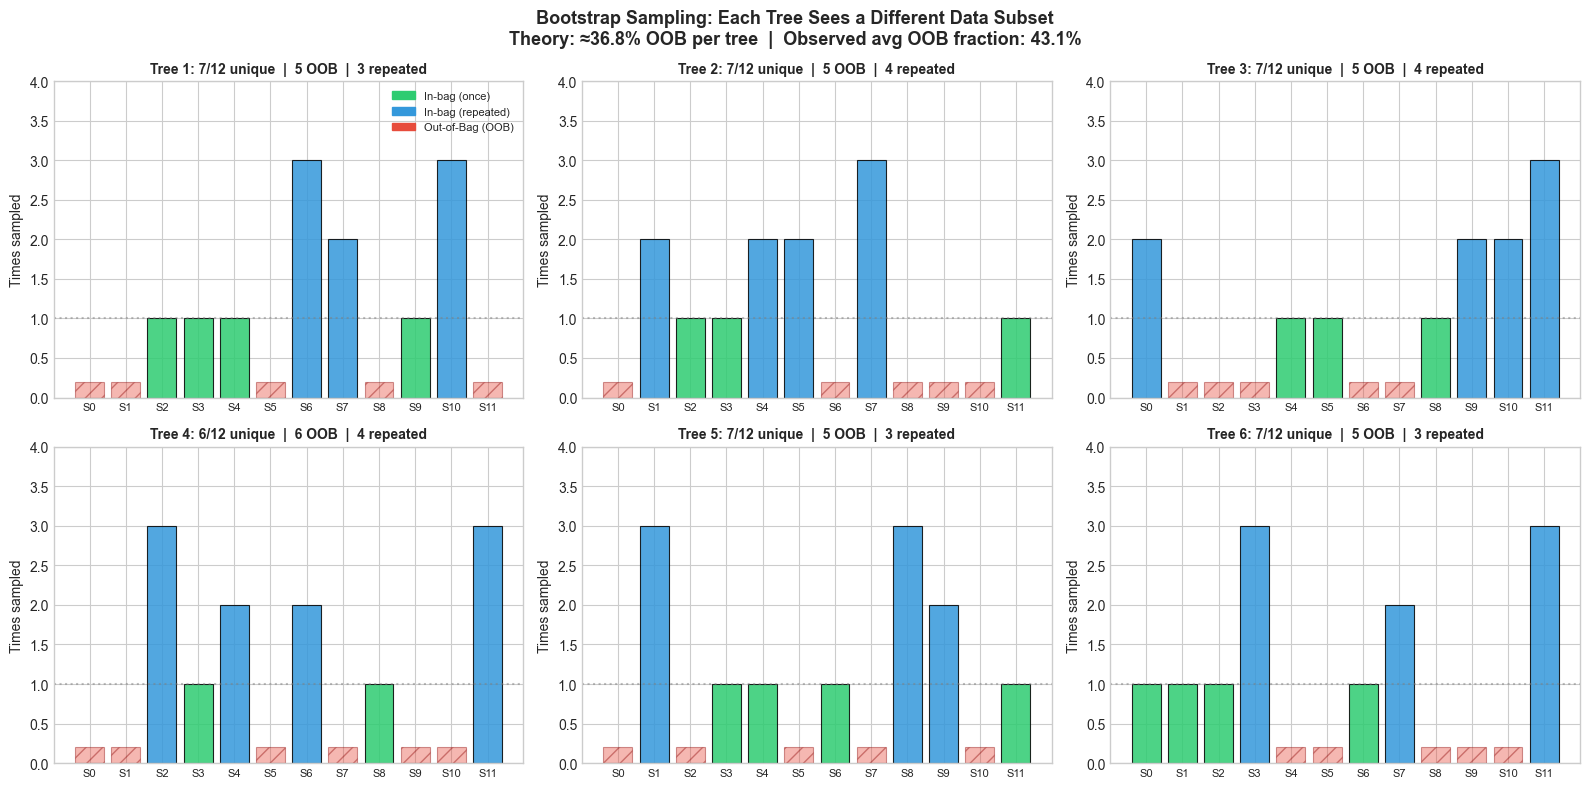

In [50]:

# ---------------------------------------------------------------
# 5.1  Bootstrap sampling illustration
# ---------------------------------------------------------------
np.random.seed(SEED)
N = 12
population = np.arange(N)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
oob_counts = np.zeros(N, dtype=int)

for tree_idx, ax in enumerate(axes.ravel()):
    bs = np.random.choice(population, size=N, replace=True)
    unique, counts = np.unique(bs, return_counts=True)
    in_bag = np.isin(population, unique)

    oob_counts += (~in_bag).astype(int)

    bar_heights = []
    bar_colors  = []
    for i in population:
        cnt = counts[unique == i][0] if i in unique else 0
        bar_heights.append(cnt)
        if i not in unique:
            bar_colors.append(RED)
        elif cnt > 1:
            bar_colors.append(BLUE)
        else:
            bar_colors.append(GREEN)

    # Draw in-bag bars at their true count
    ax.bar(population, bar_heights, color=bar_colors,
           edgecolor='k', linewidth=0.8, alpha=0.85)

    # Draw OOB samples as hatched stubs so they're visible but clearly "not sampled"
    for i, h in enumerate(bar_heights):
        if h == 0:
            ax.bar(i, 0.2, color=RED, alpha=0.4,
                   edgecolor='darkred', lw=0.8, hatch='//')

    n_oob = N - len(unique)
    n_rep = int(np.sum(np.array(bar_heights) > 1))
    ax.set_title(f'Tree {tree_idx+1}: {len(unique)}/12 unique  |  {n_oob} OOB  |  {n_rep} repeated',
                 fontsize=10, fontweight='bold')
    ax.set_xticks(population)
    ax.set_xticklabels([f'S{i}' for i in population], fontsize=8)
    ax.set_ylabel('Times sampled')
    ax.set_ylim(0, 4)
    ax.axhline(1, color='gray', ls=':', alpha=0.5)

    if tree_idx == 0:
        patch_in  = mpatches.Patch(color=GREEN, label='In-bag (once)')
        patch_rep = mpatches.Patch(color=BLUE,  label='In-bag (repeated)')
        patch_oob = mpatches.Patch(color=RED,   hatch='//', label='Out-of-Bag (OOB)')
        ax.legend(handles=[patch_in, patch_rep, patch_oob], fontsize=8, loc='upper right')

n_trees = len(axes.ravel())
overall_oob_pct = oob_counts.mean() / n_trees * 100
plt.suptitle(
    f'Bootstrap Sampling: Each Tree Sees a Different Data Subset\n'
    f'Theory: ≈36.8% OOB per tree  |  Observed avg OOB fraction: {overall_oob_pct:.1f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

> **Key Takeaway:** Each tree sees a **different bootstrap sample** — so trees make different
> mistakes. Averaging many uncorrelated errors reduces variance without increasing bias.
> The OOB samples (not seen by each tree) give a **free estimate of test error**.

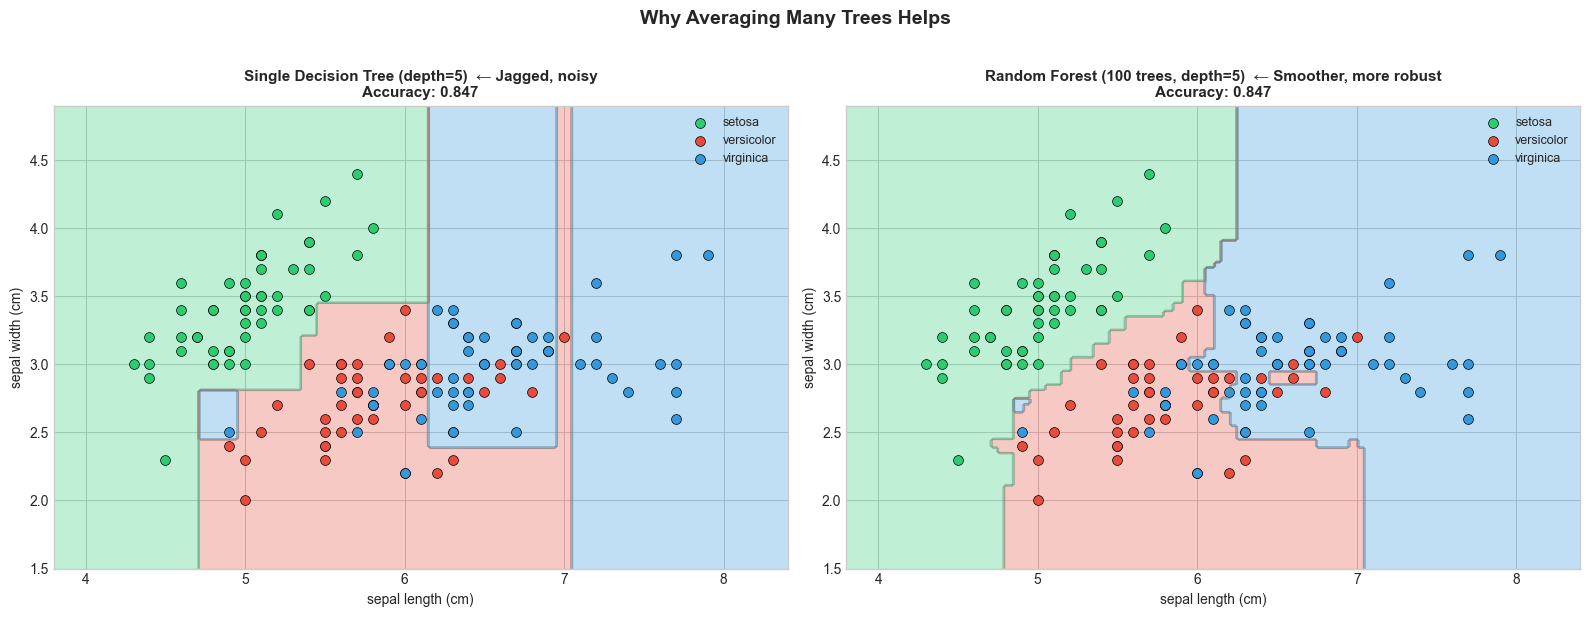

In [51]:
# ---------------------------------------------------------------
# 5.2  Decision boundaries: 1 Tree vs Random Forest
# ---------------------------------------------------------------
X_2d = X_iris[:, :2]
single_tree = DecisionTreeClassifier(max_depth=5, random_state=SEED)
rf_model    = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED)
single_tree.fit(X_2d, y_iris)
rf_model.fit(X_2d, y_iris)

h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, title in zip(axes,
                             [single_tree, rf_model],
                             ['Single Decision Tree (depth=5)  ← Jagged, noisy',
                              'Random Forest (100 trees, depth=5)  ← Smoother, more robust']):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3,
                cmap=ListedColormap([GREEN + '55', RED + '55', BLUE + '55']))
    ax.contour(xx, yy, Z, colors='grey', linewidths=0.4, alpha=0.5)
    for idx, (name, color) in enumerate(zip(iris.target_names, [GREEN, RED, BLUE])):
        mask = y_iris == idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=name, edgecolors='k', s=50, linewidths=0.5)
    acc = model.score(X_2d, y_iris)
    ax.set_title(f'{title}\nAccuracy: {acc:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])
    ax.legend(fontsize=9)

plt.suptitle('Why Averaging Many Trees Helps', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

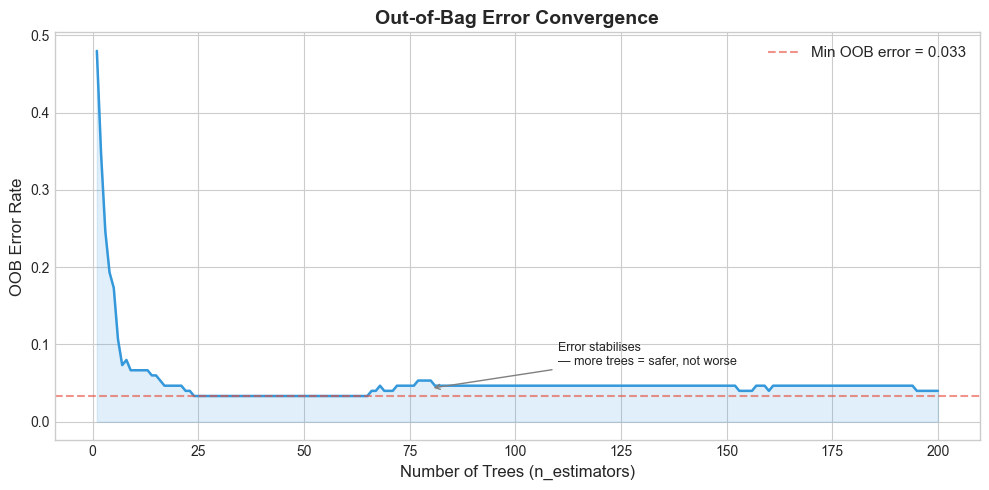

In [52]:
# ---------------------------------------------------------------
# 5.3  Out-of-Bag error convergence
# ---------------------------------------------------------------
n_estimator_range = np.arange(1, 201)
oob_errors = []

for n in n_estimator_range:
    rf_oob = RandomForestClassifier(n_estimators=n, oob_score=True,
                                    random_state=SEED)
    rf_oob.fit(X_iris, y_iris)
    oob_errors.append(1 - rf_oob.oob_score_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_estimator_range, oob_errors, color=BLUE, lw=1.8)
ax.fill_between(n_estimator_range, oob_errors, alpha=0.15, color=BLUE)
ax.axhline(min(oob_errors), color=RED, ls='--', alpha=0.6,
           label=f'Min OOB error = {min(oob_errors):.3f}')
ax.annotate('Error stabilises\n— more trees = safer, not worse',
            xy=(80, min(oob_errors)+0.01), xytext=(110, min(oob_errors)+0.04),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
ax.set_xlabel('Number of Trees (n_estimators)', fontsize=12)
ax.set_ylabel('OOB Error Rate', fontsize=12)
ax.set_title('Out-of-Bag Error Convergence', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

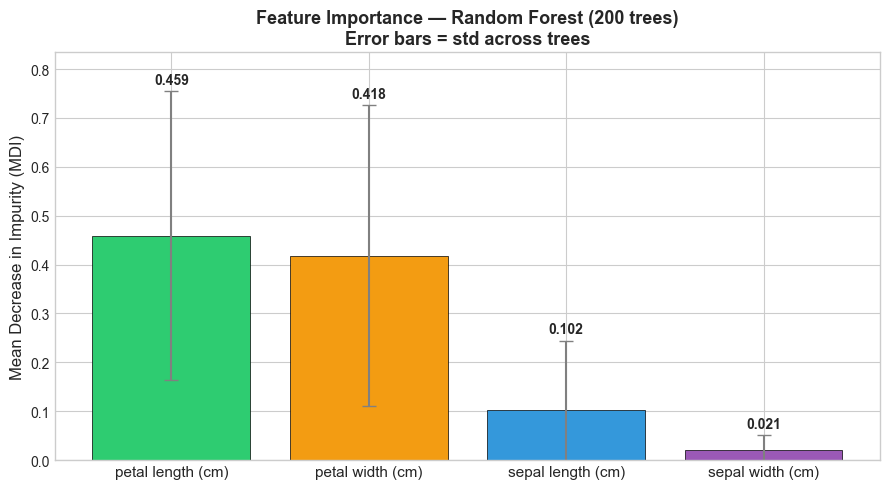


> petal length and petal width dominate — makes biological sense for Iris species.


In [53]:
# ---------------------------------------------------------------
# 5.4  Feature importance with uncertainty (error bars)
# ---------------------------------------------------------------
rf_full = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_full.fit(X_iris, y_iris)

importances = rf_full.feature_importances_
tree_importances = np.array([t.feature_importances_ for t in rf_full.estimators_])
imp_std = tree_importances.std(axis=0)

sorted_idx = np.argsort(importances)[::-1]
feature_names_sorted = [iris.feature_names[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(importances)),
              importances[sorted_idx],
              yerr=imp_std[sorted_idx],
              capsize=5,
              color=[GREEN, ORANGE, BLUE, PURPLE],
              edgecolor='k', linewidth=0.5,
              error_kw={'elinewidth': 1.5, 'ecolor': 'gray'})

ax.set_xticks(range(len(importances)))
ax.set_xticklabels(feature_names_sorted, fontsize=11)
ax.set_ylabel('Mean Decrease in Impurity (MDI)', fontsize=12)
ax.set_title('Feature Importance — Random Forest (200 trees)\nError bars = std across trees',
             fontsize=13, fontweight='bold')

# Labels above the error cap, with enough padding
for i, (val, std) in enumerate(zip(importances[sorted_idx], imp_std[sorted_idx])):
    ax.text(i, val + std + 0.015, f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Extend y-axis so labels don't clip
ax.set_ylim(0, importances[sorted_idx[0]] + imp_std[sorted_idx[0]] + 0.08)
plt.tight_layout()
plt.show()

print('\n> petal length and petal width dominate — makes biological sense for Iris species.')

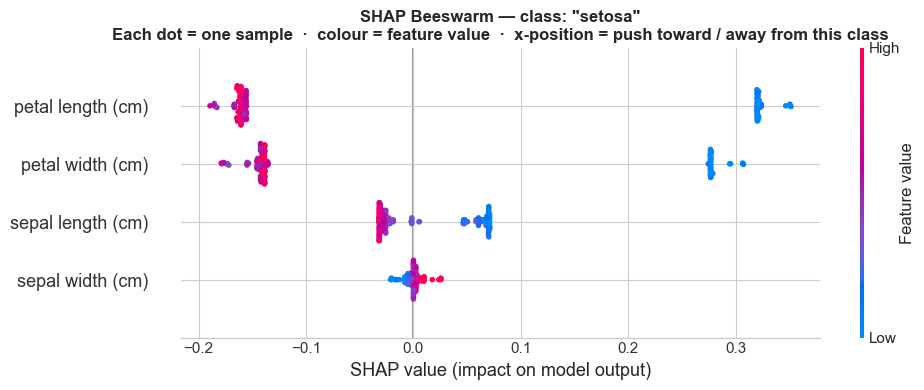

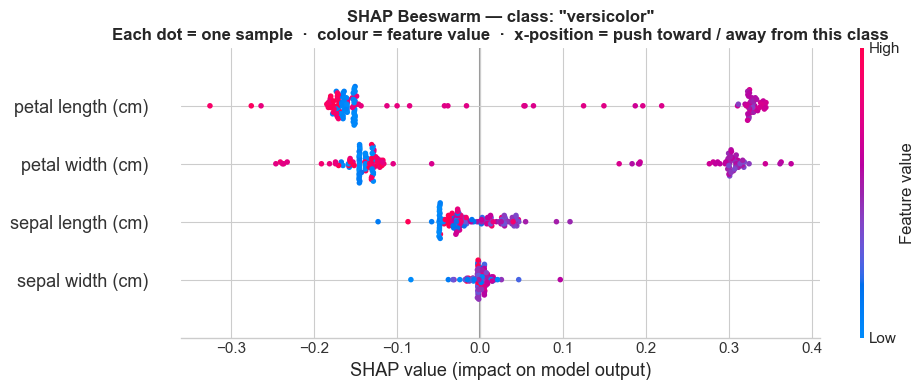

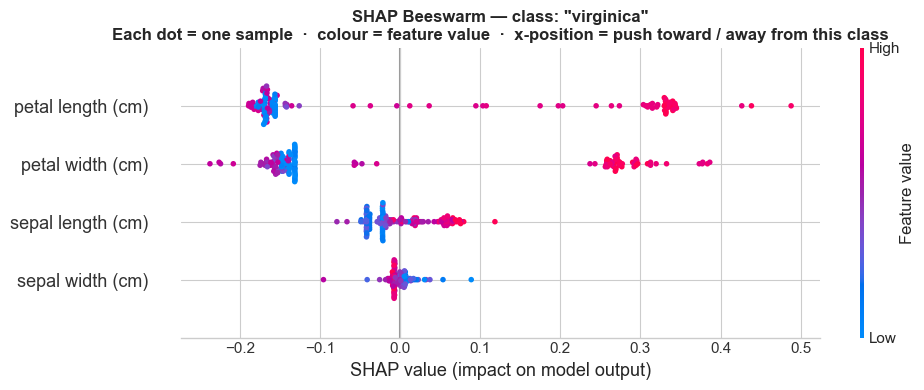

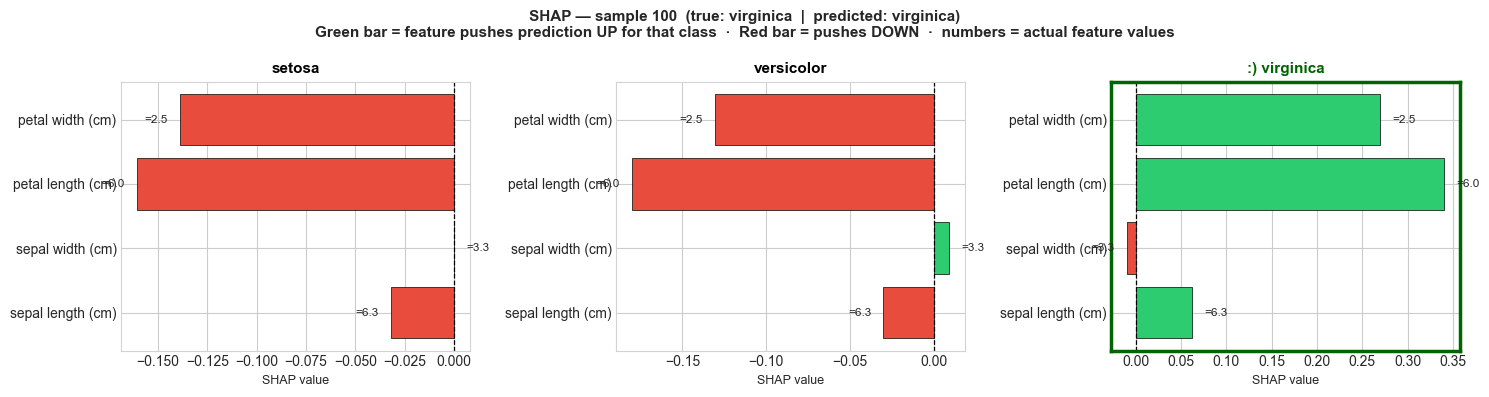


Key difference from MDI feature importance:
  MDI  → how much each feature reduces impurity on average (no direction, global only)
  SHAP → how much each feature shifts the output, per sample, with direction (+/-)


In [61]:
# ---------------------------------------------------------------
# 5.4b  SHAP — direction & magnitude of feature effects
#        (MDI tells you *how much*; SHAP also tells you *which way*)
# ---------------------------------------------------------------
# pip install shap   ← run once if needed
import shap

# TreeExplainer is exact and fast for tree-based models
explainer   = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_iris)
# shap_values → list of 3 arrays (one per class), each shape (150, 4)
# Positive SHAP value → feature pushes prediction toward this class
# Negative SHAP value → feature pushes prediction away from this class

# Handle both legacy (list) and newer (3-D array) shap return formats
if not isinstance(shap_values, list):
    shap_values = [shap_values[:, :, c] for c in range(shap_values.shape[2])]

# ── 1. Beeswarm summary for each class
for cls_idx, cls_name in enumerate(iris.target_names):
    shap.summary_plot(
        shap_values[cls_idx],
        X_iris,
        feature_names=list(iris.feature_names),
        plot_size=(10, 4),
        show=False
    )
    plt.title(
        f'SHAP Beeswarm — class: "{cls_name}"\n'
        'Each dot = one sample  ·  colour = feature value  ·  '
        'x-position = push toward / away from this class',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

# ── 2. Per-sample bar chart: why did the model predict "virginica" for sample 100?
sample_idx = 100
pred_cls   = rf_full.predict(X_iris[[sample_idx]])[0]
true_cls   = y_iris[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for cls_idx, (cls_name, ax) in enumerate(zip(iris.target_names, axes)):
    sv   = shap_values[cls_idx][sample_idx]          # (4,) SHAP values
    cols = [GREEN if v >= 0 else RED for v in sv]
    ax.barh(list(iris.feature_names), sv, color=cols, edgecolor='k', linewidth=0.5)
    ax.axvline(0, color='k', lw=0.9, ls='--')

    # Annotate each bar with the actual feature value
    pad = max(abs(sv)) * 0.04
    for fi, (feat_val, sv_val) in enumerate(zip(X_iris[sample_idx], sv)):
        xpos = sv_val + (pad if sv_val >= 0 else -pad)
        ax.text(xpos, fi, f'={feat_val:.1f}',
                ha='left' if sv_val >= 0 else 'right',
                va='center', fontsize=8.5)

    is_pred = (cls_idx == pred_cls)
    for spine in ax.spines.values():
        spine.set_edgecolor('darkgreen' if is_pred else 'lightgray')
        spine.set_linewidth(2.5 if is_pred else 0.8)
    ax.set_title(f'{":) " if is_pred else ""}{cls_name}',
                 fontsize=11, fontweight='bold',
                 color='darkgreen' if is_pred else 'black')
    ax.set_xlabel('SHAP value', fontsize=9)

plt.suptitle(
    f'SHAP — sample {sample_idx}  '
    f'(true: {iris.target_names[true_cls]}  |  predicted: {iris.target_names[pred_cls]})\n'
    'Green bar = feature pushes prediction UP for that class  ·  '
    'Red bar = pushes DOWN  ·  numbers = actual feature values',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('\nKey difference from MDI feature importance:')
print('  MDI  → how much each feature reduces impurity on average (no direction, global only)')
print('  SHAP → how much each feature shifts the output, per sample, with direction (+/-)')


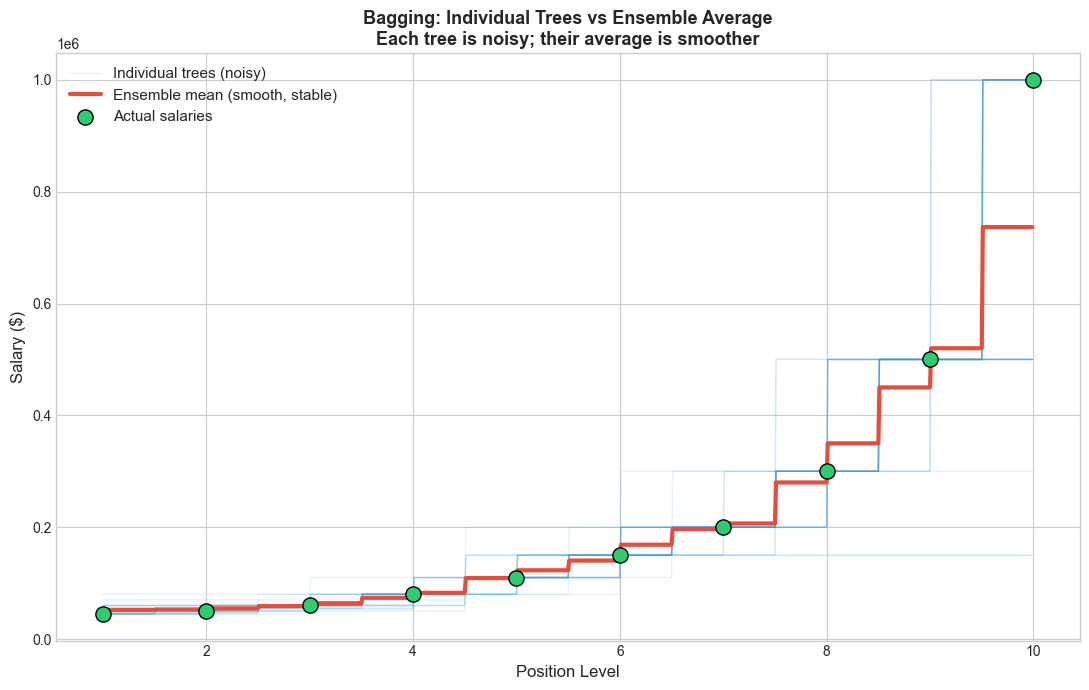

In [54]:
# ---------------------------------------------------------------
# 5.5  Bagging reduces variance: individual trees vs ensemble
# ---------------------------------------------------------------
rf_sal = RandomForestRegressor(n_estimators=30, max_depth=4, random_state=SEED)
rf_sal.fit(X_sal, y_sal)

fig, ax = plt.subplots(figsize=(11, 7))

for i, tree_est in enumerate(rf_sal.estimators_):
    label = 'Individual trees (noisy)' if i == 0 else None
    ax.plot(X_grid_sal, tree_est.predict(X_grid_sal),
            color=BLUE, alpha=0.12, lw=1, label=label)

y_rf = rf_sal.predict(X_grid_sal)
ax.plot(X_grid_sal, y_rf, color=RED, lw=3,
        label='Ensemble mean (smooth, stable)')
ax.scatter(X_sal, y_sal, c=GREEN, edgecolors='k', s=120, zorder=5, label='Actual salaries')

ax.set_xlabel('Position Level', fontsize=12)
ax.set_ylabel('Salary ($)', fontsize=12)
ax.set_title('Bagging: Individual Trees vs Ensemble Average\n'
             'Each tree is noisy; their average is smoother',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

> **Key Takeaway:** Each individual tree (blue, transparent) is a high-variance
> step function. Their average (red) is much smoother and more stable.
> This variance reduction with no increase in bias is the core benefit of bagging.

> ⚠️ **Random Forest does NOT overfit as you add more trees** — more trees = lower variance
> (unlike boosting, which can overfit). But training time grows linearly with `n_estimators`.

---
## Section 6: Hyperparameter Tuning & Practical Tips

### Key hyperparameters

| Parameter | What it controls | Default |
|-----------|-----------------|--------|
| `n_estimators` | Number of trees | 100 |
| `max_depth` | Max tree depth (overfitting control) | None |
| `min_samples_split` | Min samples to split a node | 2 |
| `min_samples_leaf` | Min samples in a leaf | 1 |
| `max_features` | Features per split: `'sqrt'` (clf) / `'log2'` | `'sqrt'` |
| `ccp_alpha` | Post-pruning strength | 0 |

**Strategy:** Start with defaults → check OOB score → tune `max_depth` first, then `min_samples_split`.

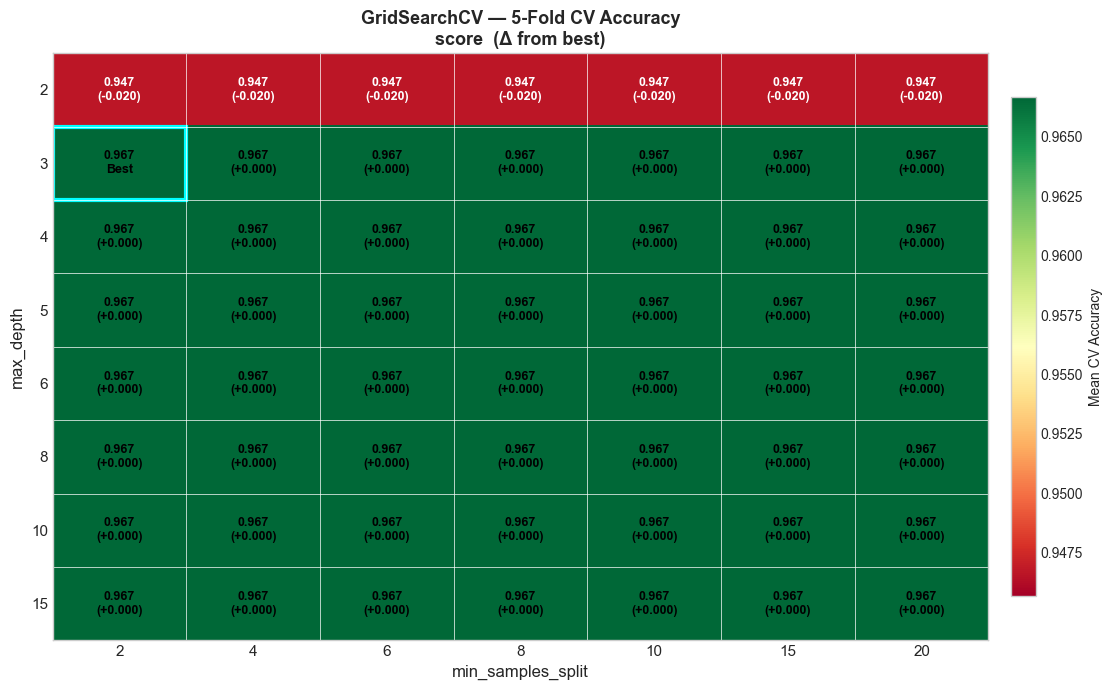

Best params : {'max_depth': 3, 'min_samples_split': 2}
Best CV acc : 0.9667


In [55]:
# ---------------------------------------------------------------
# 6.1  GridSearchCV — heatmap of CV scores
# ---------------------------------------------------------------
param_grid = {
    'max_depth':        [2, 3, 4, 5, 6, 8, 10, 15],
    'min_samples_split':[2, 4, 6, 8, 10, 15, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=SEED),
    param_grid, cv=5, scoring='accuracy',
    return_train_score=True, n_jobs=-1
)
grid_search.fit(X_iris, y_iris)

scores = grid_search.cv_results_['mean_test_score'].reshape(
    len(param_grid['max_depth']),
    len(param_grid['min_samples_split'])
)

best_score = scores.max()
best_row, best_col = np.unravel_index(np.argmax(scores), scores.shape)

fig, ax = plt.subplots(figsize=(12, 7))
ax.grid(False)  # suppress seaborn-whitegrid lines bleeding through imshow

im = ax.imshow(scores, interpolation='nearest', cmap='RdYlGn',
               aspect='auto', vmin=scores.min() - 0.001, vmax=scores.max())

ax.set_xticks(range(len(param_grid['min_samples_split'])))
ax.set_xticklabels(param_grid['min_samples_split'], fontsize=11)
ax.set_yticks(range(len(param_grid['max_depth'])))
ax.set_yticklabels(param_grid['max_depth'], fontsize=11)
ax.set_xlabel('min_samples_split', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)
ax.set_title('GridSearchCV — 5-Fold CV Accuracy\nscore  (Δ from best)',
             fontsize=13, fontweight='bold')

# Draw thin cell separators manually (clean lines, not the whitegrid bleed)
for x in np.arange(-0.5, len(param_grid['min_samples_split']), 1):
    ax.axvline(x, color='white', lw=0.5)
for y in np.arange(-0.5, len(param_grid['max_depth']), 1):
    ax.axhline(y, color='white', lw=0.5)

# Annotate every cell: score + delta from best
threshold = (scores.max() + scores.min()) / 2
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        val = scores[i, j]
        delta = val - best_score
        txt_color = 'black' if val > threshold else 'white'
        label = f'{val:.3f}\nBest' if (i == best_row and j == best_col) \
                else f'{val:.3f}\n({delta:+.3f})'
        ax.text(j, i, label, ha='center', va='center',
                fontsize=9, color=txt_color, fontweight='bold')

# Cyan border on the best cell
ax.add_patch(plt.Rectangle((best_col - 0.5, best_row - 0.5), 1, 1,
             fill=False, edgecolor='cyan', lw=3))

plt.colorbar(im, ax=ax, label='Mean CV Accuracy', shrink=0.85, pad=0.02)
plt.tight_layout()
plt.show()

print(f'Best params : {grid_search.best_params_}')
print(f'Best CV acc : {grid_search.best_score_:.4f}')

         Model  Train   Test  CV (5-fold)  CV std
    Default RF 1.0000 0.8889       0.9667  0.0211
      Tuned RF 0.9714 0.9111       0.9667  0.0211
Tree (depth=3) 0.9810 0.9778       0.9733  0.0249
   Tree (full) 1.0000 0.9333       0.9533  0.0340

⚠  Test set = 45 samples only — single-split accuracy is noisy.
   Use CV (5-fold) as the reliable metric.



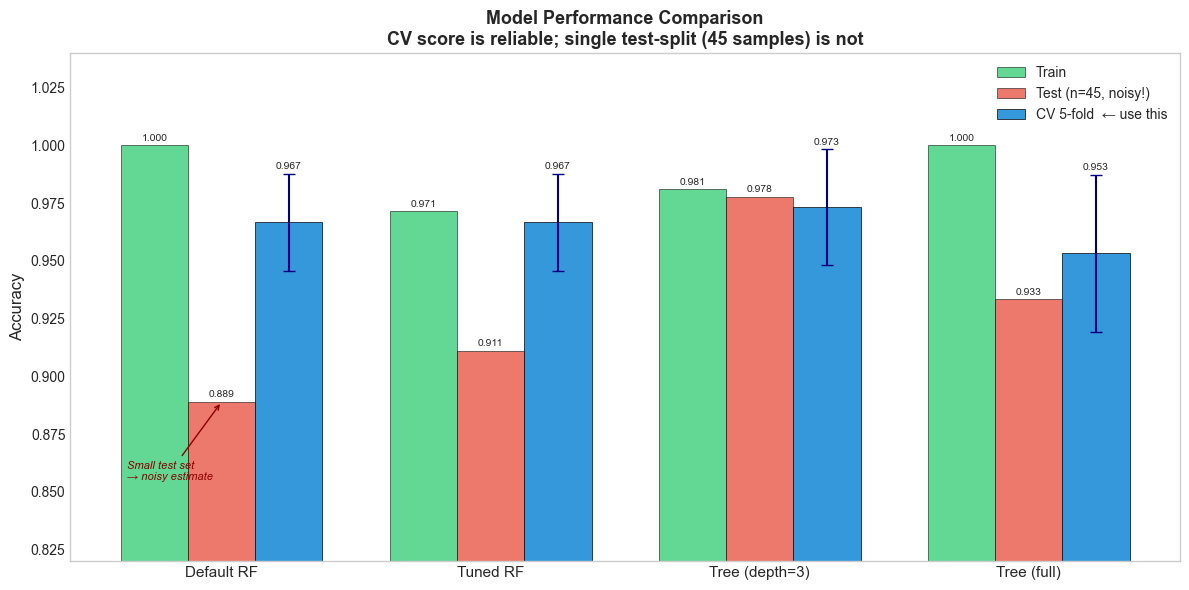

In [57]:
# ---------------------------------------------------------------
# 6.2  Model comparison: default vs tuned RF vs single tree
# ---------------------------------------------------------------
param_grid_wide = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [3, 5, 8, None],
    'min_samples_split':[2, 5, 10]
}
grid_wide = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid_wide, cv=5, scoring='accuracy',
    return_train_score=True, n_jobs=-1
)
grid_wide.fit(X_train, y_train)

default_rf = RandomForestClassifier(random_state=SEED).fit(X_train, y_train)
tuned_rf   = grid_wide.best_estimator_
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_train, y_train)
dt_full    = DecisionTreeClassifier(random_state=SEED).fit(X_train, y_train)

models_compare = {
    'Default RF': default_rf,
    'Tuned RF':   tuned_rf,
    'Tree (depth=3)': dt_shallow,
    'Tree (full)': dt_full,
}

results = []
for name, model in models_compare.items():
    cv_scores = cross_val_score(model, X_iris, y_iris, cv=5)
    results.append({
        'Model':       name,
        'Train':       model.score(X_train, y_train),
        'Test':        model.score(X_test,  y_test),
        'CV (5-fold)': cv_scores.mean(),
        'CV std':      cv_scores.std(),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))
print(f'\n⚠  Test set = {len(y_test)} samples only — single-split accuracy is noisy.')
print('   Use CV (5-fold) as the reliable metric.\n')

# --- Bar chart ---
x_pos = np.arange(len(results))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.grid(False)

b1 = ax.bar(x_pos - width, results_df['Train'],       width, label='Train',
            color=GREEN, edgecolor='k', lw=0.5, alpha=0.75)
b2 = ax.bar(x_pos,         results_df['Test'],        width,
            label=f'Test (n={len(y_test)}, noisy!)',
            color=RED,   edgecolor='k', lw=0.5, alpha=0.75)
b3 = ax.bar(x_pos + width, results_df['CV (5-fold)'], width,
            yerr=results_df['CV std'], capsize=4,
            label='CV 5-fold  ← use this', color=BLUE, edgecolor='k', lw=0.5,
            error_kw={'elinewidth': 1.5, 'ecolor': 'navy'})

ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison\n'
             'CV score is reliable; single test-split (45 samples) is not',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.82, 1.04)
ax.legend(fontsize=10)

# Label each BarContainer directly — avoids the ErrorbarContainer in ax.containers
for bar_group in (b1, b2, b3):
    ax.bar_label(bar_group, fmt='%.3f', fontsize=7.5, padding=2)

ax.annotate('Small test set\n→ noisy estimate', xy=(0, 0.889), xytext=(-0.35, 0.855),
            fontsize=8, color='darkred', fontstyle='italic',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1))

plt.tight_layout()
plt.show()

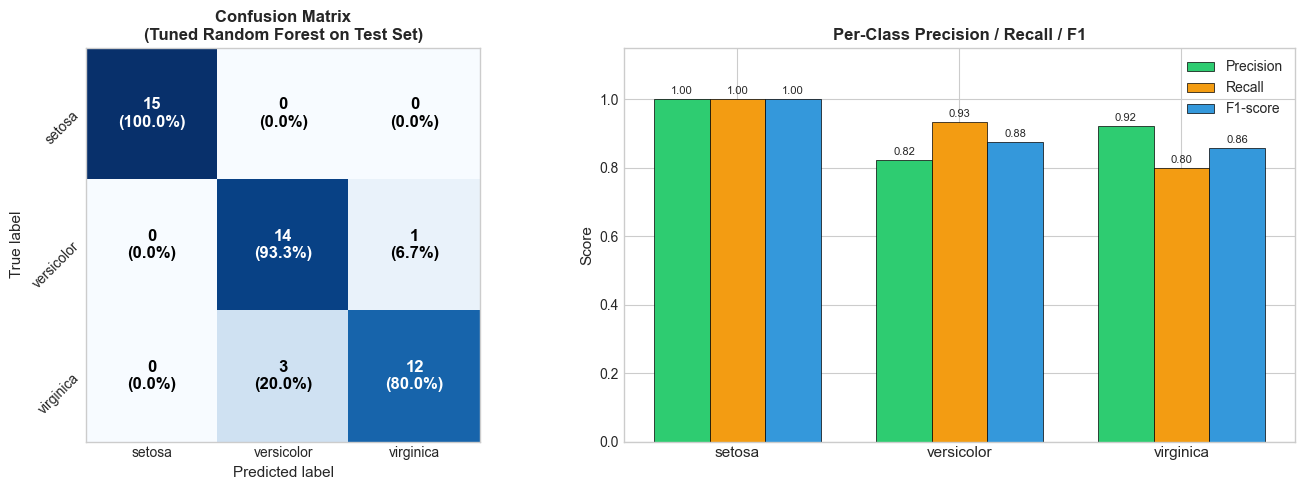


=== Full Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [58]:
# ---------------------------------------------------------------
# 6.3  Full evaluation: confusion matrix + classification report
# ---------------------------------------------------------------
best_model = tuned_rf
y_pred     = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion matrix (custom: count + row-% per cell, no grid bleed) ---
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[0].grid(False)

n_cls = len(iris.target_names)
for i in range(n_cls):
    for j in range(n_cls):
        txt_color = 'white' if cm_norm[i, j] > 0.55 else 'black'
        axes[0].text(j, i,
                     f'{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)',
                     ha='center', va='center',
                     fontsize=12, fontweight='bold', color=txt_color)

axes[0].set_xticks(range(n_cls))
axes[0].set_xticklabels(iris.target_names, fontsize=10)
axes[0].set_yticks(range(n_cls))
axes[0].set_yticklabels(iris.target_names, fontsize=10, rotation=45, ha='right')
axes[0].set_xlabel('Predicted label', fontsize=11)
axes[0].set_ylabel('True label', fontsize=11)
axes[0].set_title('Confusion Matrix\n(Tuned Random Forest on Test Set)',
                  fontsize=12, fontweight='bold')

# --- Per-class Precision / Recall / F1 bar chart ---
report  = classification_report(y_test, y_pred,
                                 target_names=iris.target_names,
                                 output_dict=True)
metrics  = ['precision', 'recall', 'f1-score']
x_cls    = np.arange(n_cls)
width    = 0.25
colors_m = [GREEN, ORANGE, BLUE]

for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    vals = [report[name][metric] for name in iris.target_names]
    bars = axes[1].bar(x_cls + i * width, vals, width,
                       label=metric.capitalize(), color=color,
                       edgecolor='k', linewidth=0.5)
    axes[1].bar_label(bars, fmt='%.2f', fontsize=8, padding=2)

axes[1].set_xticks(x_cls + width)
axes[1].set_xticklabels(iris.target_names, fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Per-Class Precision / Recall / F1',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print('\n=== Full Classification Report ===')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

> **Key Takeaway:** Accuracy alone hides per-class performance.
> Always inspect **precision, recall, and F1** especially on imbalanced datasets.
>
> - **Precision:** Of all predicted class X, how many are actually X?
> - **Recall:** Of all actual class X, how many did we catch?
> - **F1:** Harmonic mean of precision and recall

---
## Summary

| Concept | Core Idea |
|---------|----------|
| **Decision Tree (CART)** | Greedily splits on the feature/threshold that most reduces impurity |
| **Gini vs Entropy** | Nearly identical in practice; both 0 = pure, max at p=0.5 |
| **Axis-aligned boundaries** | Trees approximate any boundary with axis-parallel cuts |
| **Regression Tree** | Predicts leaf mean; produces step functions |
| **Overfitting** | Deep tree memorises training data; fix with `max_depth`, `ccp_alpha` |
| **Bias-Variance** | Shallow = underfitting (high bias); deep = overfitting (high variance) |
| **Bootstrap** | ≈63% unique per tree; ≈37% OOB = free validation |
| **Random Forest** | Bagging + feature randomness → diverse trees → lower variance |
| **Feature importance** | MDI = mean decrease in impurity across all trees |

### When to use trees/forests
✅ Tabular data (mixed types)  
✅ No feature scaling required  
✅ Need interpretable model (single tree)  
✅ Excellent baseline (Random Forest)  

### When NOT to use
❌ Very high-dimensional sparse data (text, images — use neural nets)  
❌ When extrapolation is needed (trees can't predict outside training range)  
❌ When you need smooth probability estimates (calibrate with `CalibratedClassifierCV`)  

---

## Section 7: Practice Exercises

### Conceptual (no code)

**Q1.** A node contains 10 samples: 8 class A, 2 class B. Compute its Gini impurity.  
*(Answer: 2 × 0.8 × 0.2 = 0.32)*

**Q2.** Why does a fully grown decision tree (no `max_depth`) almost always overfit?  
*(Hint: what does the training accuracy look like?)*

**Q3.** A Random Forest with 500 trees takes too long to train. Which hyperparameter
do you reduce first, and why is it safer to reduce than `max_depth`?

**Q4.** Why can't a decision tree extrapolate beyond its training range? Give a concrete example.

**Q5.** What is the difference between **bagging** and **boosting**? Which one can overfit as
you add more estimators?

---

### Coding exercises

**E1. Compute information gain manually**  
Given: 12 samples — 7 positive, 5 negative.  
Candidate split creates left (6 pos, 1 neg) and right (1 pos, 4 neg).  
Write Python to compute the Gini-based information gain.

**E2. Visualise a wine dataset tree**
```python
from sklearn.datasets import load_wine
# 1. Load wine dataset
# 2. Train a DecisionTreeClassifier with max_depth=4
# 3. Plot the tree with plot_tree()
# 4. Print the rules with export_text()
# 5. Report training accuracy and number of leaves
```

**E3. Random Forest with OOB score**
```python
# 1. Train RandomForestClassifier(oob_score=True) on wine data
# 2. Compare OOB score vs 5-fold cross-validation score
# 3. Plot feature importances
# 4. Which 3 features matter most?
```

**E4. Find the optimal depth**
```python
# For the wine dataset:
# 1. Plot train vs test accuracy for max_depth = 1..20
# 2. Identify the sweet spot (best test accuracy)
# 3. Try ccp_alpha pruning — does it beat max_depth?
```

**E5. (Challenge) Real-world classification**  
Load the Telco churn CSV from the Code folder and:
1. Preprocess: encode categorical features, handle missing values
2. Train a Random Forest classifier
3. Plot confusion matrix and classification report
4. Identify the top 5 most important features for churn prediction
5. Are they what you expected? What business actions do they suggest?

---
*End of Lecture 5 — Decision Trees & Random Forests*